In [77]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [83]:
from google.colab import files
uploaded = files.upload()

Saving diabetes_unclean - diabetes_unclean.csv to diabetes_unclean - diabetes_unclean (1).csv


In [85]:
df = pd.read_csv("diabetes_unclean - diabetes_unclean.csv")

In [86]:
df.head()
df.shape
df.columns


Index(['ID', 'No_Pation', 'Gender', 'AGE', 'Urea', 'Cr', 'HbA1c', 'Chol', 'TG',
       'HDL', 'LDL', 'VLDL', 'BMI', 'CLASS'],
      dtype='object')

In [87]:
df.columns = df.columns.str.strip()

In [88]:
df.drop(["ID", "No_Pation"], axis=1, inplace=True)

In [89]:
df["Gender"] = df["Gender"].replace({
    'f': 'F',
    'm': 'M',
    'Female': 'F',
    'Male': 'M'
})

In [90]:
numeric_cols = df.select_dtypes(include=np.number).columns

for col in numeric_cols:
    df[col].fillna(df[col].mean(), inplace=True)

categorical_cols = df.select_dtypes(include='object').columns

for col in categorical_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

/tmp/ipykernel_5328/2000810006.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mean(), inplace=True)
/tmp/ipykernel_5328/2000810006.py:9: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try usin

In [91]:
df.columns

Index(['Gender', 'AGE', 'Urea', 'Cr', 'HbA1c', 'Chol', 'TG', 'HDL', 'LDL',
       'VLDL', 'BMI', 'CLASS'],
      dtype='object')

In [92]:
df = pd.get_dummies(df, columns=["Gender"], drop_first=True)

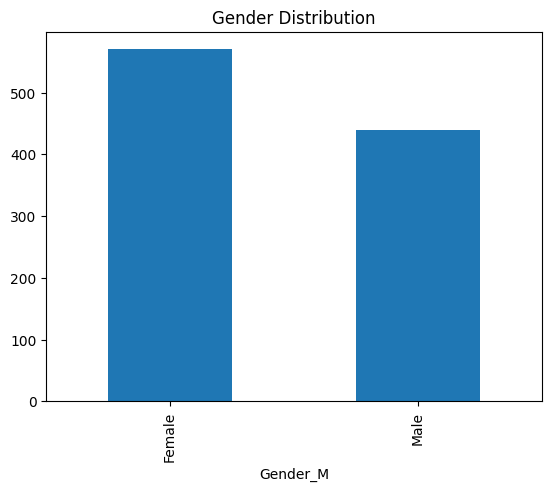

In [93]:
df["Gender_M"].value_counts().plot(kind='bar')
plt.title("Gender Distribution")
plt.xticks([0,1], ["Female","Male"])
plt.show()

/tmp/ipykernel_5328/2641053678.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['AGE'].fillna(df['AGE'].mean(), inplace=True)


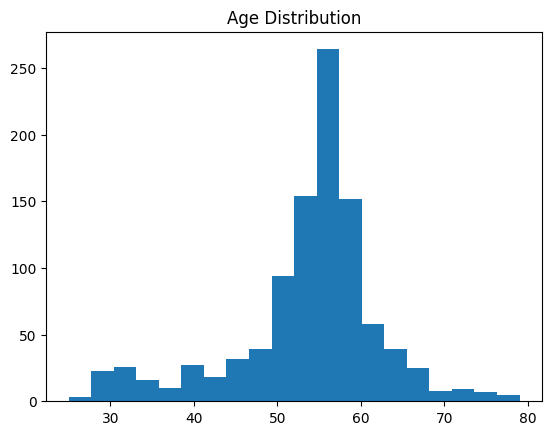

In [94]:
df['AGE'] = df['AGE'].astype(str).str.replace('\n', '').str.strip()
df['AGE'] = pd.to_numeric(df['AGE'], errors='coerce')
df['AGE'].fillna(df['AGE'].mean(), inplace=True)

plt.hist(df['AGE'], bins=20)
plt.title('Age Distribution')
plt.show()

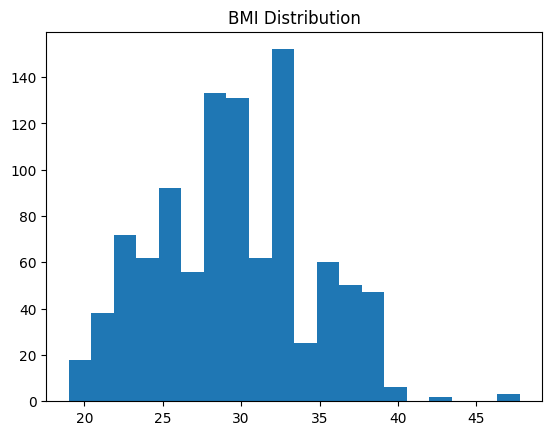

In [95]:
plt.hist(df["BMI"], bins=20)
plt.title("BMI Distribution")
plt.show()

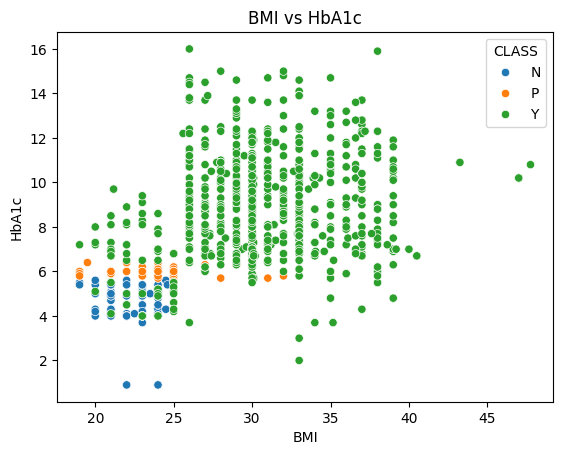

In [96]:
sns.scatterplot(x=df["BMI"], y=df["HbA1c"], hue=df["CLASS"])
plt.title("BMI vs HbA1c")
plt.show()

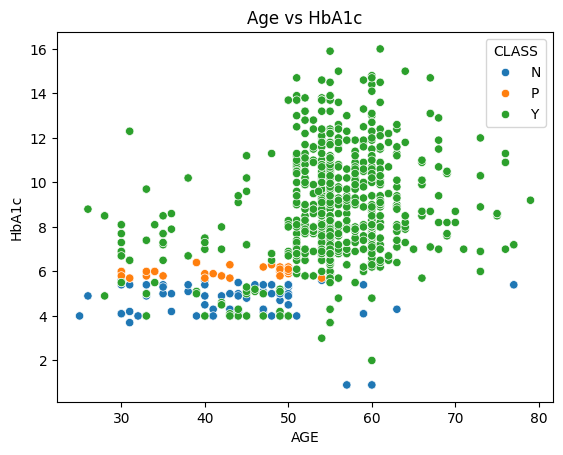

In [97]:
sns.scatterplot(x=df["AGE"], y=df["HbA1c"], hue=df["CLASS"])
plt.title("Age vs HbA1c")
plt.show()

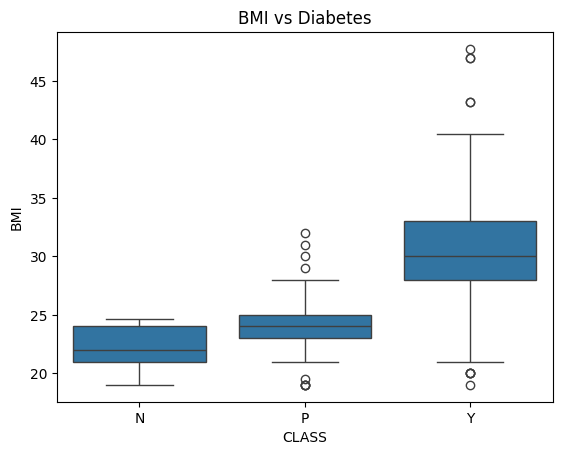

In [98]:
sns.boxplot(x=df["CLASS"], y=df["BMI"])
plt.title("BMI vs Diabetes")
plt.show()

In [99]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

In [100]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

In [101]:
X = df.drop("CLASS", axis=1)
y = df["CLASS"]

In [102]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42
)

In [103]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "SVM": SVC(),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "KNN": KNeighborsClassifier()
}

In [105]:
results = []

for name, model in models.items():

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, average='weighted', zero_division=0),
        "Recall": recall_score(y_test, y_pred, average='weighted', zero_division=0),
        "F1 Score": f1_score(y_test, y_pred, average='weighted', zero_division=0)
    })


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [106]:
results_df = pd.DataFrame(results)
results_df

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.940594,0.937511,0.940594,0.938840
1,SVM,0.848185,0.719417,0.848185,0.778512
2,Decision Tree,0.986799,0.986781,0.986799,0.986668
3,Random Forest,0.990099,0.990125,0.990099,0.990022
4,KNN,0.907591,0.919991,0.907591,0.913022


In [107]:
best_model_name = results_df.sort_values(
    by="F1 Score",
    ascending=False
).iloc[0]["Model"]

best_model_name

'Random Forest'

In [108]:
import joblib

best_model = models[best_model_name]

joblib.dump(best_model, "diabetes_model.pkl")
joblib.dump(X_train.columns.tolist(), "training_columns.pkl")

['training_columns.pkl']

In [109]:
from google.colab import files

files.download("diabetes_model.pkl")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [113]:
files.download("training_columns.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>